EfficientNetV2-S +ConvNeXt-Tiny

In [ ]:
# =========================
# INSTALL
# =========================
!pip install timm -q

# =========================
# IMPORTS
# =========================
import os
import torch
import timm
import numpy as np
import json
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from torch.amp import autocast, GradScaler

# =========================
# CONFIG
# =========================
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
PATIENCE = 6

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# DATA TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# =========================
# DATASET
# =========================
data_dir = "/content/drive/My Drive/Knee Osteoarthritis Classification"

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=test_transform)
test_dataset  = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=test_transform)

NUM_CLASSES = len(train_dataset.classes)
class_names = train_dataset.classes

# =========================
# HISTORY STORAGE (NEW)
# =========================
history_path = "/content/drive/MyDrive/knee_oa_history.json"

train_losses = []
val_losses = []
train_acc_list = []
val_acc_list = []

# =========================
# OVERSAMPLING
# =========================
targets = train_dataset.targets

class_sample_count = np.array(
    [len(np.where(np.array(targets) == t)[0]) for t in np.unique(targets)]
)

weights = 1. / class_sample_count
samples_weight = np.array([weights[t] for t in targets])
samples_weight = torch.from_numpy(samples_weight).float()

sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =========================
# CLASS WEIGHTS
# =========================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_dataset.targets),
    y=train_dataset.targets
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

# =========================
# ATTENTION BLOCK
# =========================
class Attention(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(in_features, in_features//2),
            nn.ReLU(),
            nn.Linear(in_features//2, in_features),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.attn(x)

# =========================
# HYBRID MODEL
# =========================
class HybridModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.eff = timm.create_model("tf_efficientnetv2_s", pretrained=True, num_classes=0)
        self.conv = timm.create_model("convnext_tiny", pretrained=True, num_classes=0)

        for p in self.eff.parameters():
            p.requires_grad = False
        for p in self.conv.parameters():
            p.requires_grad = False

        with torch.no_grad():
            dummy = torch.randn(1,3,224,224)
            f1 = self.eff(dummy)
            f2 = self.conv(dummy)
            self.feat_dim = f1.shape[1] + f2.shape[1]

        self.attn = Attention(self.feat_dim)

        self.classifier = nn.Sequential(
            nn.Linear(self.feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        f1 = self.eff(x)
        f2 = self.conv(x)
        x = torch.cat([f1, f2], dim=1)
        x = self.attn(x)
        return self.classifier(x)

model = HybridModel(NUM_CLASSES).to(device)

# =========================
# OPTIMIZER
# =========================
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

scaler = GradScaler("cuda")

# =========================
# TRAINING
# =========================
best_acc = 0
trigger = 0

for epoch in range(EPOCHS):

    if epoch == 5:
        print("Unfreezing backbone...")
        for p in model.parameters():
            p.requires_grad = True

    # ================= TRAIN =================
    model.train()
    running_loss = 0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / len(train_dataset)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = correct / len(val_dataset)

    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}: Train={train_acc:.4f} Val={val_acc:.4f}")

    # ================= SAVE BEST MODEL =================
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        trigger = 0
    else:
        trigger += 1

    if trigger >= PATIENCE:
        print("Early stopping...")
        break

    # ================= STORE HISTORY (NEW) =================
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_acc_list,
        "val_acc": val_acc_list
    }

    with open(history_path, "w") as f:
        json.dump(history, f)

# =========================
# LOAD BEST MODEL
# =========================
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# =========================
# TEST PREDICTION
# =========================
all_preds, all_labels = [], []

for images, labels in test_loader:
    images = images.to(device)
    outputs = model(images)

    preds = outputs.argmax(1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch 1: Train=0.5450 Val=0.6065
Epoch 2: Train=0.6360 Val=0.6685
Epoch 3: Train=0.6683 Val=0.6491
Epoch 4: Train=0.6907 Val=0.6667
Epoch 5: Train=0.6963 Val=0.6889
Unfreezing backbone...
Epoch 6: Train=0.6963 Val=0.6991
Epoch 7: Train=0.7333 Val=0.6324
Epoch 8: Train=0.7733 Val=0.7333
Epoch 9: Train=0.8085 Val=0.6972
Epoch 10: Train=0.8016 Val=0.7241
Epoch 11: Train=0.8378 Val=0.7750
Epoch 12: Train=0.8566 Val=0.7991
Epoch 13: Train=0.8772 Val=0.7824
Epoch 14: Train=0.8841 Val=0.7778
Epoch 15: Train=0.9032 Val=0.7907
Epoch 16: Train=0.9021 Val=0.7954
Epoch 17: Train=0.9114 Val=0.8417
Epoch 18: Train=0.9246 Val=0.8037
Epoch 19: Train=0.9267 Val=0.8120
Epoch 20: Train=0.9230 Val=0.8296
Epoch 21: Train=0.9278 Val=0.8361
Epoch 22: Train=0.9368 Val=0.8481
Epoch 23: Train=0.9325 Val=0.8398
Epoch 24: Train=0.9333 Val=0.8426
Epoch 25: Train=0.9434 Val=0.8426
Epoch 26: Train=0.9376 Val=0.8380
Epoch 27: Train=0.9349 Val=0.8454
Epoch 28: Train=0.9323 Val=0.8389
Early stopping...
              pr

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


EfficientNetV2-S + ConvNeXt-Tiny

In [2]:
# =========================
# INSTALL
# =========================
!pip install timm -q

# =========================
# IMPORTS
# =========================
import os, json
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

from sklearn.metrics import classification_report, confusion_matrix

from torch.amp import autocast, GradScaler

# =========================
# CONFIG
# =========================
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
PATIENCE = 7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# TRANSFORMS (STRONG BUT SAFE)
# =========================
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# =========================
# DATASET
# =========================
data_dir = "/content/drive/My Drive/Knee Osteoarthritis Classification"

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=test_transform)
test_dataset  = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=test_transform)

class_names = train_dataset.classes

# =========================
# ✅ ONLY OVERSAMPLING (NO CLASS WEIGHTS)
# =========================
targets = train_dataset.targets

class_sample_count = np.array(
    [len(np.where(np.array(targets) == t)[0]) for t in np.unique(targets)]
)

weights = 1. / class_sample_count
samples_weight = np.array([weights[t] for t in targets])
samples_weight = torch.from_numpy(samples_weight).float()

sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)  # smaller for GPU safety

# =========================
# ATTENTION BLOCK
# =========================
class Attention(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(in_features, in_features//2),
            nn.ReLU(),
            nn.Linear(in_features//2, in_features),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.attn(x)

# =========================
# HYBRID MODEL
# =========================
class HybridModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.eff = timm.create_model("tf_efficientnetv2_s", pretrained=True, num_classes=0)
        self.conv = timm.create_model("convnext_tiny", pretrained=True, num_classes=0)

        for p in self.eff.parameters():
            p.requires_grad = False
        for p in self.conv.parameters():
            p.requires_grad = False

        with torch.no_grad():
            dummy = torch.randn(1,3,224,224)
            f1 = self.eff(dummy)
            f2 = self.conv(dummy)
            self.feat_dim = f1.shape[1] + f2.shape[1]

        self.attn = Attention(self.feat_dim)

        self.classifier = nn.Sequential(
            nn.Linear(self.feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),   # optimized
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        f1 = self.eff(x)
        f2 = self.conv(x)
        x = torch.cat([f1, f2], dim=1)
        x = self.attn(x)
        return self.classifier(x)

model = HybridModel(len(class_names)).to(device)

# =========================
# LOSS
# =========================
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# =========================
# OPTIMIZER (IMPORTANT FIX)
# =========================
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

scaler = GradScaler("cuda")

# =========================
# HISTORY STORAGE
# =========================
history_path = "/content/drive/MyDrive/knee_history.json"

train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

# =========================
# TRAINING
# =========================
best_acc = 0
trigger = 0

for epoch in range(EPOCHS):

    # 🔥 DELAYED UNFREEZE (IMPORTANT)
    if epoch == 10:
        print("Unfreezing backbone...")
        for p in model.parameters():
            p.requires_grad = True

        optimizer = optim.AdamW(model.parameters(), lr=3e-5)

    # TRAIN
    model.train()
    running_loss = 0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / len(train_dataset)

    # VALIDATION
    model.eval()
    val_loss = 0
    correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = correct / len(val_dataset)

    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}: Train={train_acc:.4f} Val={val_acc:.4f}")

    # SAVE BEST
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pth")
        trigger = 0
    else:
        trigger += 1

    if trigger >= PATIENCE:
        print("Early stopping...")
        break

    # STORE HISTORY
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    history = {
        "train_loss": train_loss_list,
        "val_loss": val_loss_list,
        "train_acc": train_acc_list,
        "val_acc": val_acc_list
    }

    with open(history_path, "w") as f:
        json.dump(history, f)

# =========================
# TEST (SAFE - NO OOM)
# =========================
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

Epoch 1: Train=0.6529 Val=0.6926
Epoch 2: Train=0.6981 Val=0.6306
Epoch 3: Train=0.7008 Val=0.6713
Epoch 4: Train=0.7304 Val=0.6954
Epoch 5: Train=0.7339 Val=0.7222
Epoch 6: Train=0.7238 Val=0.7204
Epoch 7: Train=0.7376 Val=0.7204
Epoch 8: Train=0.7569 Val=0.7000
Epoch 9: Train=0.7524 Val=0.7093
Epoch 10: Train=0.7624 Val=0.6981
Unfreezing backbone...
Epoch 11: Train=0.7193 Val=0.7315
Epoch 12: Train=0.7667 Val=0.7130
Epoch 13: Train=0.7960 Val=0.7120
Epoch 14: Train=0.8079 Val=0.7454
Epoch 15: Train=0.8270 Val=0.7787
Epoch 16: Train=0.8392 Val=0.7583
Epoch 17: Train=0.8627 Val=0.7731
Epoch 18: Train=0.8772 Val=0.8343
Epoch 19: Train=0.8899 Val=0.8074
Epoch 20: Train=0.8825 Val=0.8315
Epoch 21: Train=0.8820 Val=0.8241
Epoch 22: Train=0.9000 Val=0.8111
Epoch 23: Train=0.9079 Val=0.8315
Epoch 24: Train=0.9063 Val=0.8269
Epoch 25: Train=0.9196 Val=0.8481
Epoch 26: Train=0.9132 Val=0.8602
Epoch 27: Train=0.9180 Val=0.8509
Epoch 28: Train=0.9198 Val=0.8417
Epoch 29: Train=0.9220 Val=0.8583


Accuracy & Loss Curves

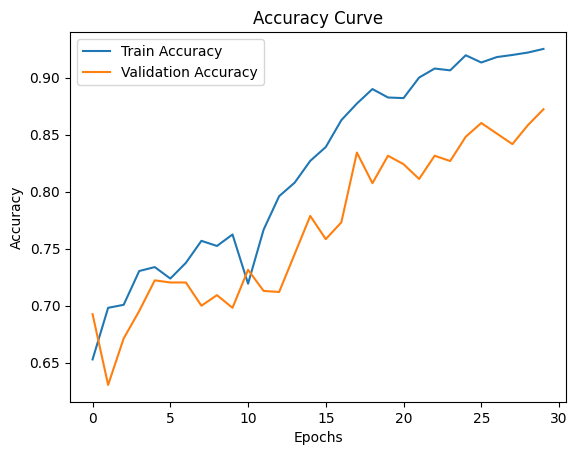

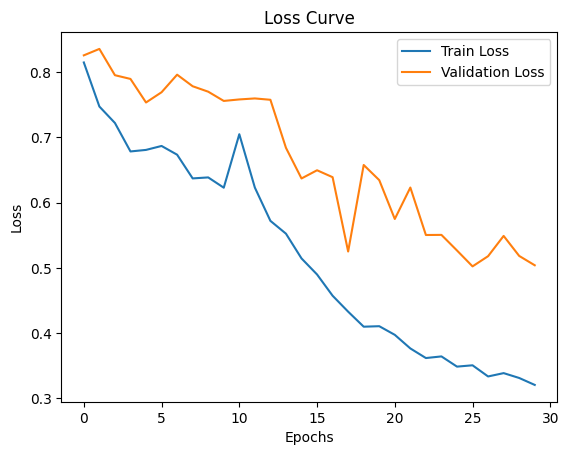

In [3]:
import json
import matplotlib.pyplot as plt

history_path = "/content/drive/MyDrive/knee_history.json"

with open(history_path, "r") as f:
    history = json.load(f)

train_acc = history["train_acc"]
val_acc = history["val_acc"]
train_loss = history["train_loss"]
val_loss = history["val_loss"]

# ================= ACCURACY CURVE =================
plt.figure()
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

# ================= LOSS CURVE =================
plt.figure()
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

Confusion Matrix

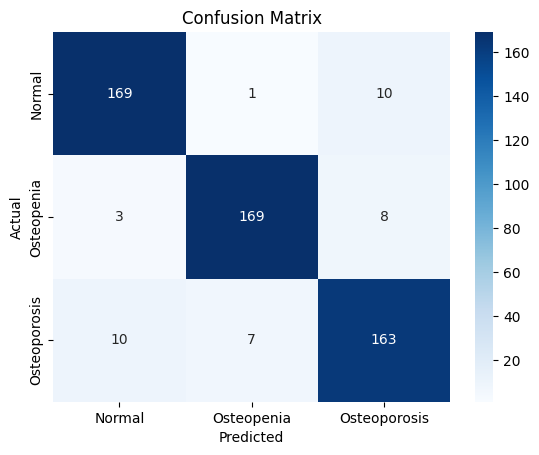

In [4]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ROC Curve (Multi-class)

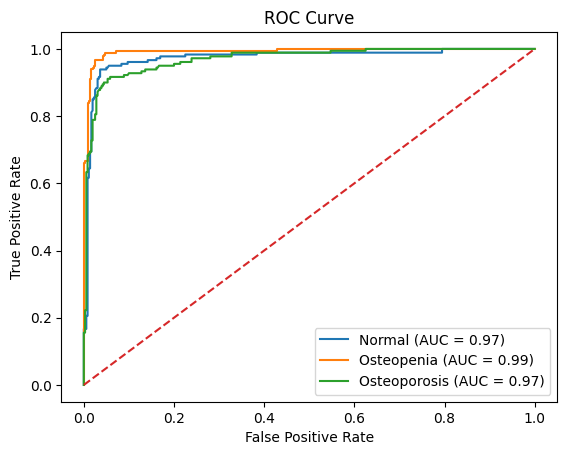

In [5]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert labels to one-hot
y_true = label_binarize(all_labels, classes=[0,1,2])

# Get probabilities
model.eval()
probs = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())

probs = np.array(probs)

# Plot ROC
plt.figure()

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Accuracy, Precision, Recall Graph

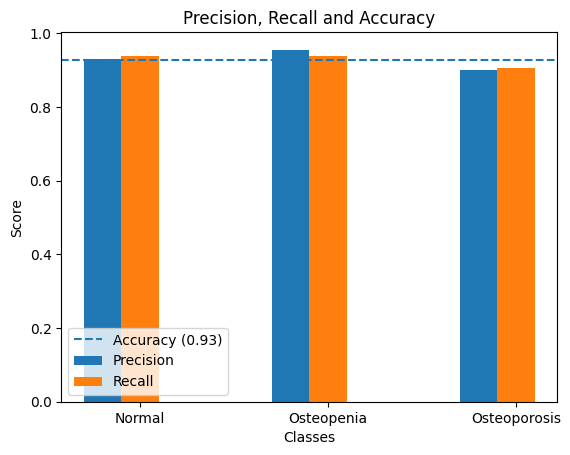

In [6]:
from sklearn.metrics import precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# =========================
# CALCULATE METRICS
# =========================
accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(all_labels, all_preds, average=None)
recall = recall_score(all_labels, all_preds, average=None)

# =========================
# BAR GRAPH PER CLASS
# =========================
x = np.arange(len(class_names))

plt.figure()
plt.bar(x - 0.2, precision, width=0.2, label="Precision")
plt.bar(x, recall, width=0.2, label="Recall")

# Accuracy as horizontal line
plt.axhline(y=accuracy, linestyle='--', label=f"Accuracy ({accuracy:.2f})")

plt.xticks(x, class_names)
plt.xlabel("Classes")
plt.ylabel("Score")
plt.title("Precision, Recall and Accuracy")
plt.legend()
plt.show()

Accuracy, Precision, Recall Graph,F1 Score


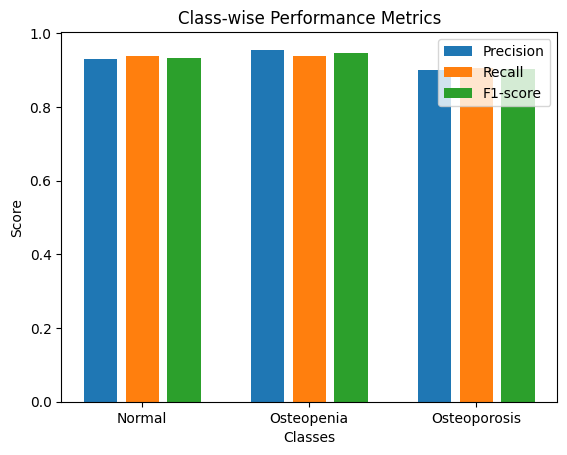

In [7]:
from sklearn.metrics import f1_score

f1 = f1_score(all_labels, all_preds, average=None)

plt.figure()
plt.bar(x - 0.25, precision, width=0.2, label="Precision")
plt.bar(x, recall, width=0.2, label="Recall")
plt.bar(x + 0.25, f1, width=0.2, label="F1-score")

plt.xticks(x, class_names)
plt.xlabel("Classes")
plt.ylabel("Score")
plt.title("Class-wise Performance Metrics")
plt.legend()
plt.show()

store predictions

In [9]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

CLASSIFICATION REPORT VALUES (Precision/Recall/F1)

In [11]:
from sklearn.metrics import classification_report
report = classification_report(all_labels, all_preds,
                               target_names=class_names,
                               output_dict=True)

BAR PLOT (Precision, Recall, F1 with values on top)

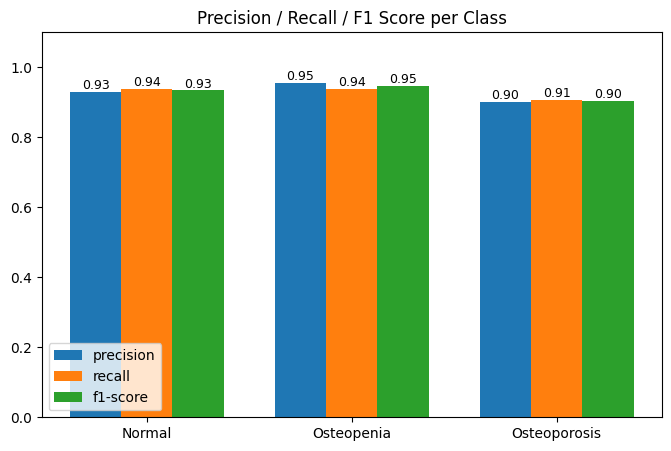

In [12]:
import numpy as np

metrics = ["precision", "recall", "f1-score"]
classes = class_names

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(8,5))

for i, metric in enumerate(metrics):
    values = [report[c][metric] for c in classes]
    bars = plt.bar(x + i*width, values, width, label=metric)

    # 👉 values on top of bars
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height(),
                 f"{bar.get_height():.2f}",
                 ha='center', va='bottom', fontsize=9)

plt.xticks(x + width, classes)
plt.ylim(0, 1.1)
plt.title("Precision / Recall / F1 Score per Class")
plt.legend()
plt.show()

ROC CURVE (MULTI CLASS)

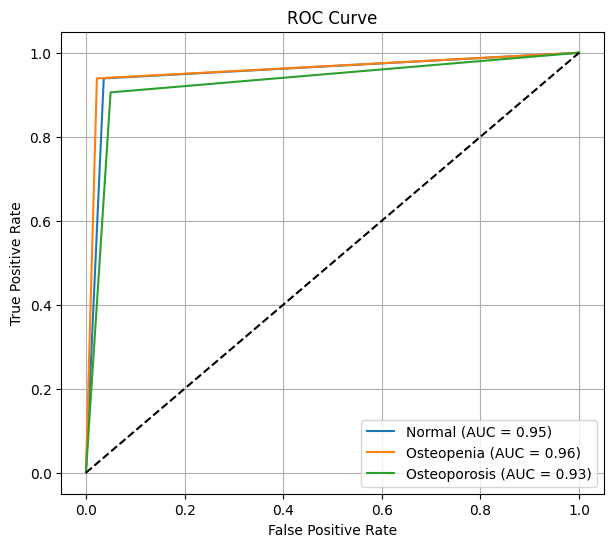

In [15]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(class_names)

y_true = label_binarize(all_labels, classes=range(n_classes))
y_pred = label_binarize(all_preds, classes=range(n_classes))

plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

Installing library

In [16]:
!pip install opencv-python matplotlib -q

Grad-CAM implementation

In [17]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

Hook to capture feature maps + gradients

In [18]:
feature_maps = None
gradients = None

def forward_hook(module, input, output):
    global feature_maps
    feature_maps = output

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

Attach hooks to EfficientNet backbone

In [19]:
# last convolution layer of EfficientNet
target_layer = model.eff.blocks[-1]

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

Grad-CAM function

In [20]:
def generate_gradcam(image_tensor, class_idx=None):
    model.eval()

    image_tensor = image_tensor.unsqueeze(0).to(device)

    output = model(image_tensor)

    if class_idx is None:
        class_idx = output.argmax(1).item()

    score = output[0, class_idx]

    model.zero_grad()
    score.backward()

    # gradients + feature maps
    pooled_grads = torch.mean(gradients, dim=[0, 2, 3])

    feature_maps_cpu = feature_maps.detach()[0]

    for i in range(feature_maps_cpu.shape[0]):
        feature_maps_cpu[i, :, :] *= pooled_grads[i]

    heatmap = torch.mean(feature_maps_cpu, dim=0).cpu().numpy()
    heatmap = np.maximum(heatmap, 0)

    heatmap /= np.max(heatmap)

    return heatmap

Visualization function

In [21]:
def show_gradcam(image_tensor, heatmap, alpha=0.5):

    img = image_tensor.permute(1,2,0).cpu().numpy()
    img = img * [0.229,0.224,0.225] + [0.485,0.456,0.406]
    img = np.clip(img, 0, 1)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = heatmap * alpha + img * 255
    overlay = np.uint8(overlay)

    plt.figure(figsize=(6,3))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(heatmap)
    plt.title("Heatmap")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Grad-CAM")

    plt.show()

Run on a test image

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


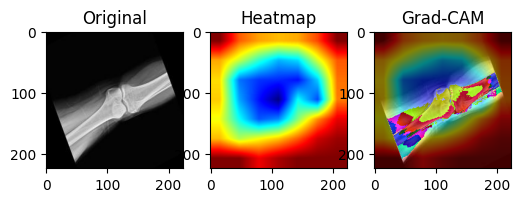

In [22]:
# take one sample image
images, labels = next(iter(test_loader))

img = images[0]
label = labels[0]

heatmap = generate_gradcam(img)
show_gradcam(img, heatmap)

MULTI-IMAGE GRAD-CAM GRID

In [23]:
import matplotlib.pyplot as plt

def gradcam_grid(images, labels, num_images=6):
    model.eval()
    fig, axes = plt.subplots(2, 3, figsize=(10, 7))

    for i in range(num_images):
        img = images[i]
        label = labels[i]

        heatmap = generate_gradcam(img)

        # original image
        orig = img.permute(1,2,0).cpu().numpy()
        orig = orig * [0.229,0.224,0.225] + [0.485,0.456,0.406]
        orig = np.clip(orig, 0, 1)

        heatmap_resized = cv2.resize(heatmap, (224,224))
        heatmap_color = cv2.applyColorMap(np.uint8(255*heatmap_resized), cv2.COLORMAP_JET)
        overlay = heatmap_color * 0.4 + orig * 255
        overlay = np.uint8(overlay)

        ax = axes[i//3, i%3]
        ax.imshow(overlay)
        ax.set_title(class_names[label.item()])
        ax.axis("off")

    plt.tight_layout()
    plt.show()

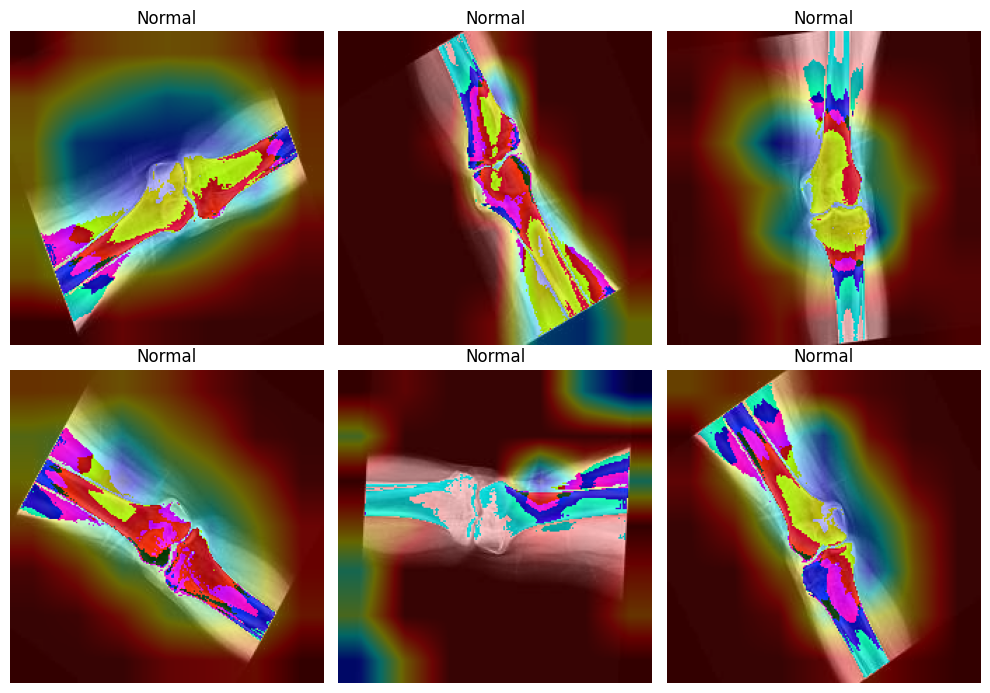

In [24]:
images, labels = next(iter(test_loader))
gradcam_grid(images, labels, num_images=6)

CLASS-WISE GRAD-CAM COMPARISON

In [25]:
def classwise_gradcam(test_loader, samples_per_class=1):

    model.eval()
    selected = {0: None, 1: None, 2: None}

    for images, labels in test_loader:
        for i in range(len(labels)):
            cls = labels[i].item()
            if selected[cls] is None:
                selected[cls] = images[i]
        if all(v is not None for v in selected.values()):
            break

    fig, axes = plt.subplots(1, 3, figsize=(12,4))

    for i, cls in enumerate(selected.keys()):
        img = selected[cls]
        heatmap = generate_gradcam(img)

        orig = img.permute(1,2,0).cpu().numpy()
        orig = orig * [0.229,0.224,0.225] + [0.485,0.456,0.406]
        orig = np.clip(orig, 0, 1)

        heatmap = cv2.resize(heatmap, (224,224))
        heatmap = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)

        overlay = heatmap * 0.4 + orig * 255
        overlay = np.uint8(overlay)

        axes[i].imshow(overlay)
        axes[i].set_title(class_names[cls])
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

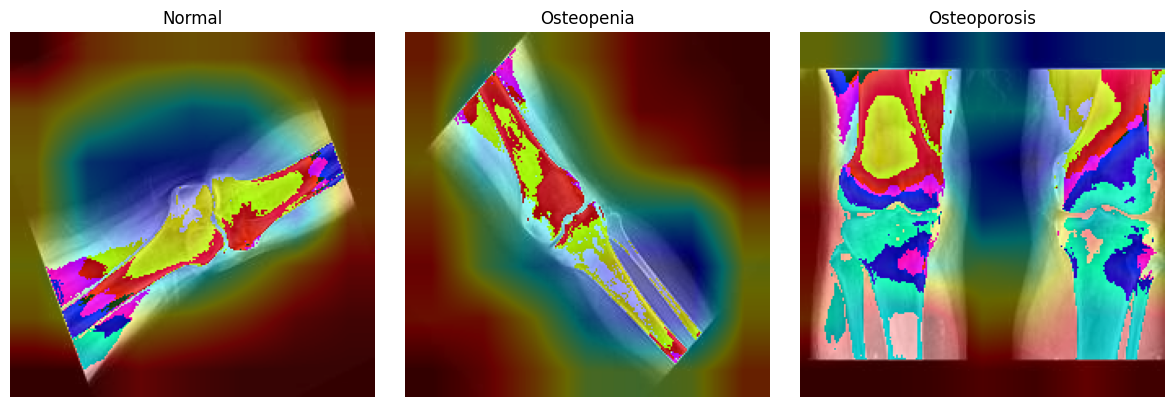

In [26]:
classwise_gradcam(test_loader)

ATTENTION HEATMAP Extract Attention weights

In [27]:
attention_maps = []

def hook_attention(module, input, output):
    attention_maps.append(output.detach().cpu())

model.attn.attn[2].register_forward_hook(hook_attention)

Visualize Attention

In [28]:
def visualize_attention(image):

    model.eval()
    attention_maps.clear()

    img = image.unsqueeze(0).to(device)

    with torch.no_grad():
        _ = model(img)

    attn = attention_maps[0][0].numpy()

    plt.figure(figsize=(10,3))

    plt.subplot(1,2,1)
    plt.imshow(attn.reshape(-1,1), cmap='hot')
    plt.title("Attention Weights (Fusion Layer)")
    plt.colorbar()

    plt.subplot(1,2,2)
    plt.plot(attn)
    plt.title("Attention Distribution")

    plt.show()

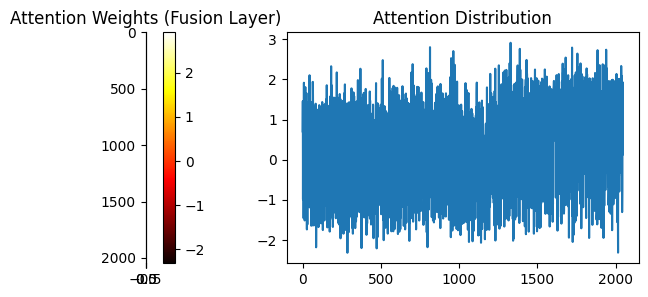

In [29]:
img = images[0]
visualize_attention(img)